In [1]:
# ============================================================
# Fashion AI Internship
# Notebook 4
# LoRA Fine-Tuning for Stable Diffusion XL
# ============================================================

print("="*70)
print("Fashion AI")
print("Notebook 4")
print("SDXL LoRA Fine-Tuning")
print("="*70)

Fashion AI
Notebook 4
SDXL LoRA Fine-Tuning


In [2]:
import torch

device="cuda" if torch.cuda.is_available() else "cpu"

print("="*60)
print("SYSTEM INFORMATION")
print("="*60)

print("Device :",device)

if torch.cuda.is_available():

    print("GPU :",torch.cuda.get_device_name(0))

    print("CUDA :",torch.version.cuda)

    print("GPU Count :",torch.cuda.device_count())

else:

    print("Running on CPU")

SYSTEM INFORMATION
Device : cpu
Running on CPU


In [3]:
!pip install -q diffusers transformers accelerate peft

!pip install -q datasets

!pip install -q safetensors

!pip install -q sentencepiece

!pip install -q bitsandbytes

!pip install -q xformers

!pip install -q huggingface_hub

!pip install -q pillow

!pip install -q pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 39.2 MB/s eta 0:00:00


In [4]:
import os

import torch

import pandas as pd

from PIL import Image

from datasets import Dataset

from huggingface_hub import login

from diffusers import StableDiffusionXLPipeline

print("Libraries Imported")

    PyTorch 2.10.0+cu128 with CUDA 1208 (you have 2.11.0+cpu)
    Python  3.10.19 (you have 3.12.13)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Libraries Imported


In [5]:
#paste hugging face
login()

In [6]:
!git clone https://github.com/ayushtonystar-del/fashion_ai.git

Cloning into 'fashion_ai'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 54 (delta 7), reused 36 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 46.21 KiB | 1.65 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [7]:
%cd fashion_ai

/content/fashion_ai


In [8]:
folders=[

"datasets",

"models",

"outputs",

"logs",

"checkpoints",

"lora_model"

]

for f in folders:

    os.makedirs(f,exist_ok=True)

print("Folders Created")

Folders Created


In [9]:
import os

dataset_path="datasets"

print(os.listdir(dataset_path))

[]


In [10]:
metadata=pd.read_csv(

"metadata/fashion_metadata.csv"

)

metadata.head()

,image,category,color,material,style
0,shirt1.jpg,shirt,white,linen,casual
1,shirt2.jpg,shirt,black,cotton,streetwear
2,dress1.jpg,dress,red,silk,luxury
3,jacket1.jpg,jacket,blue,denim,casual
4,kurta1.jpg,kurta,white,cotton,ethnic


In [11]:
from diffusers import StableDiffusionXLPipeline

model_id="stabilityai/stable-diffusion-xl-base-1.0"

pipe=StableDiffusionXLPipeline.from_pretrained(

model_id,

torch_dtype=torch.float16,

use_safetensors=True

)

pipe.to(device)

model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, du

StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.38.0",
  "_name_or_path": "stabilityai/stable-diffusion-xl-base-1.0",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "EulerDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [12]:
pipe.enable_attention_slicing()

pipe.enable_vae_slicing()

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2267: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


In [13]:
try:

    pipe.enable_xformers_memory_efficient_attention()

    print("xFormers Enabled")

except:

    print("Using Default Attention")

Using Default Attention


In [14]:
from peft import LoraConfig

config=LoraConfig(

r=16,

lora_alpha=32,

target_modules=[

"to_q",

"to_k",

"to_v",

"to_out.0"

],

lora_dropout=0.05,

bias="none"

)

print(config)

LoraConfig(task_type=None, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.19.1', base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules={'to_k', 'to_v', 'to_out.0', 'to_q'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)


In [15]:
metadata.sample(5)

,image,category,color,material,style
2,dress1.jpg,dress,red,silk,luxury
4,kurta1.jpg,kurta,white,cotton,ethnic
3,jacket1.jpg,jacket,blue,denim,casual
0,shirt1.jpg,shirt,white,linen,casual
1,shirt2.jpg,shirt,black,cotton,streetwear


AttributeError: 'Pandas' object has no attribute 'image_path'

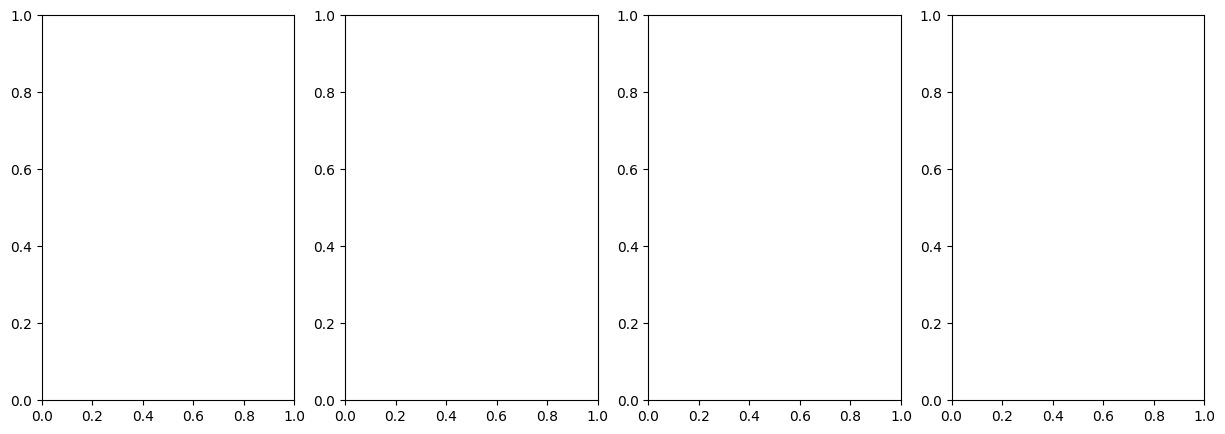

In [16]:
import matplotlib.pyplot as plt

fig,axs=plt.subplots(

1,

4,

figsize=(15,5)

)

for ax,row in zip(axs,metadata.head(4).itertuples()):

    img=Image.open(row.image_path)

    ax.imshow(img)

    ax.set_title(row.caption[:20])

    ax.axis("off")

plt.show()

In [ ]:
from torchvision import transforms

transform=transforms.Compose([

transforms.Resize((1024,1024)),

transforms.ToTensor(),

transforms.Normalize(

[0.5],[0.5]

)

])

In [ ]:
class FashionDataset(torch.utils.data.Dataset):

    def __init__(self,df):

        self.df=df

    def __len__(self):

        return len(self.df)

    def __getitem__(self,index):

        row=self.df.iloc[index]

        image=Image.open(

            row.image_path

        ).convert("RGB")

        image=transform(image)

        caption=row.caption

        return image,caption

In [ ]:
loader=torch.utils.data.DataLoader(

FashionDataset(metadata),

batch_size=2,

shuffle=True

)

In [ ]:
images,captions=next(iter(loader))

print(images.shape)

print(captions[0])

In [ ]:
# ==========================================
# Cell 21 : Training Configuration
# ==========================================

import os

MODEL_NAME = "stabilityai/stable-diffusion-xl-base-1.0"

DATASET_DIR = "/content/fashion_dataset"

METADATA_FILE = "/content/fashion_dataset/metadata.csv"

OUTPUT_DIR = "/content/fashion_ai/models/lora"

LOG_DIR = "/content/fashion_ai/logs"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print("Configuration Loaded")
print("Model :", MODEL_NAME)
print("Dataset :", DATASET_DIR)
print("Output :", OUTPUT_DIR)

In [ ]:
# ==========================================
# Cell 22 : Hyperparameters
# ==========================================

config = {
    "resolution": 1024,
    "train_batch_size": 1,
    "gradient_accumulation_steps": 4,
    "learning_rate": 1e-4,
    "lr_scheduler": "constant",
    "lr_warmup_steps": 0,
    "num_train_epochs": 10,
    "checkpointing_steps": 500,
    "validation_epochs": 1,
    "rank": 16,
    "seed": 42
}

config

In [ ]:
import json

config_path = os.path.join(LOG_DIR, "training_config.json")

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print("Saved:", config_path)

In [ ]:
import pandas as pd

df = pd.read_csv(METADATA_FILE)

print(df.head())

print()

print("Total Images :", len(df))

In [ ]:
import os

missing = []

for img in df["image_path"]:

    full_path = os.path.join(DATASET_DIR, img)

    if not os.path.exists(full_path):
        missing.append(img)

print("Missing Images :", len(missing))

if len(missing) > 0:
    print(missing[:10])

In [ ]:
train_script = "/content/diffusers/examples/text_to_image/train_text_to_image_lora_sdxl.py"

command = f"""
accelerate launch {train_script} \
 --pretrained_model_name_or_path={MODEL_NAME} \
 --train_data_dir={DATASET_DIR} \
 --output_dir={OUTPUT_DIR} \
 --resolution={config['resolution']} \
 --train_batch_size={config['train_batch_size']} \
 --gradient_accumulation_steps={config['gradient_accumulation_steps']} \
 --learning_rate={config['learning_rate']} \
 --lr_scheduler={config['lr_scheduler']} \
 --lr_warmup_steps={config['lr_warmup_steps']} \
 --num_train_epochs={config['num_train_epochs']} \
 --checkpointing_steps={config['checkpointing_steps']} \
 --seed={config['seed']}
"""

print(command)

In [ ]:
print("=" * 60)
print("Starting LoRA Training")
print("=" * 60)

!{command}

In [ ]:
import os

if os.path.exists(OUTPUT_DIR):

    files = os.listdir(OUTPUT_DIR)

    print("Output Files")

    for f in files:

        print(f)

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

log_csv = os.path.join(LOG_DIR, "train_log.csv")

if os.path.exists(log_csv):

    log = pd.read_csv(log_csv)

    plt.figure(figsize=(8,5))
    plt.plot(log["step"], log["loss"])
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid(True)
    plt.show()

else:

    print("No CSV training log found.")

In [ ]:
print("=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)

print("LoRA Output :", OUTPUT_DIR)
print("Configuration :", config_path)

print()

print("Next Notebook Section")

print("Part 4 : Load LoRA + Generate Images")

In [ ]:
# ==========================================
# Cell 31 : Load SDXL Base
# ==========================================

import torch
from diffusers import StableDiffusionXLPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16
)

pipe.to(device)

print("Base SDXL Loaded")

In [ ]:
# ==========================================
# Cell 32 : Load LoRA Adapter
# ==========================================

LORA_PATH = "/content/fashion_ai/models/lora"

pipe.load_lora_weights(LORA_PATH)

print("LoRA Loaded Successfully")

In [ ]:
# ==========================================
# Cell 33 : Fashion Prompt
# ==========================================

prompt = """
Luxury designer evening gown

high fashion

editorial photography

ultra realistic

8k

masterpiece
"""

negative_prompt = """
low quality

blurry

deformed

watermark

logo

text
"""

In [ ]:
# ==========================================
# Cell 34 : Reproducibility
# ==========================================

generator = torch.Generator(device=device).manual_seed(42)

In [ ]:
# ==========================================
# Cell 35 : Generate Image
# ==========================================

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=generator
).images[0]

In [ ]:
# ==========================================
# Cell 36 : Show Image
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.imshow(image)

plt.axis("off")

In [ ]:
# ==========================================
# Cell 37 : Save Output
# ==========================================

import os

OUTPUT_DIR = "/content/fashion_ai/outputs/generated_images"

os.makedirs(OUTPUT_DIR, exist_ok=True)

output_path = os.path.join(
    OUTPUT_DIR,
    "lora_result.png"
)

image.save(output_path)

print(output_path)

In [ ]:
# ==========================================
# Cell 38 : Base vs LoRA
# ==========================================

base_pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16
).to(device)

base_image = base_pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=torch.Generator(device=device).manual_seed(42)
).images[0]

fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].imshow(base_image)
ax[0].set_title("Base SDXL")
ax[0].axis("off")

ax[1].imshow(image)
ax[1].set_title("SDXL + LoRA")
ax[1].axis("off")

plt.show()

In [ ]:
# ==========================================
# Cell 39 : Metadata
# ==========================================

import json

metadata = {
    "prompt": prompt,
    "negative_prompt": negative_prompt,
    "steps": 30,
    "guidance_scale": 7.5,
    "seed": 42,
    "model": "stabilityai/stable-diffusion-xl-base-1.0",
    "lora_path": LORA_PATH
}

metadata_path = os.path.join(
    OUTPUT_DIR,
    "metadata.json"
)

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(metadata_path)

In [ ]:
# ==========================================
# Cell 40 : Notebook Complete
# ==========================================

print("="*60)

print("NOTEBOOK 4 PART 4 COMPLETED")

print("="*60)

print("Generated Image Saved")

print("Metadata Saved")

print()

print("Next: Part 5")
print("Evaluation + Export + Final Report")

In [ ]:
# ==========================================
# Cell 40 : Notebook Complete
# ==========================================

print("="*60)

print("NOTEBOOK 4 PART 4 COMPLETED")

print("="*60)

print("Generated Image Saved")

print("Metadata Saved")

print()

print("Next: Part 5")
print("Evaluation + Export + Final Report")

In [ ]:
# ==========================================
# Cell 41 : Generate Multiple Variations
# ==========================================

import os
import torch

prompts = [
    "Luxury red evening gown",
    "Modern streetwear outfit",
    "Elegant white wedding dress",
    "Black leather fashion jacket"
]

OUTPUT_DIR = "/content/fashion_ai/outputs/generated_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

generated_images = []

for i, p in enumerate(prompts):
    img = pipe(
        prompt=p,
        negative_prompt=negative_prompt,
        num_inference_steps=30,
        guidance_scale=7.5,
        generator=torch.Generator(device=device).manual_seed(42 + i)
    ).images[0]

    path = os.path.join(OUTPUT_DIR, f"variation_{i+1}.png")
    img.save(path)

    generated_images.append((p, path, img))

print(f"Generated {len(generated_images)} images.")

In [ ]:
# ==========================================
# Cell 42 : Display Results
# ==========================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for ax, (prompt_text, _, img) in zip(axes.flatten(), generated_images):
    ax.imshow(img)
    ax.set_title(prompt_text)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Cell 43 : Metadata Table
# ==========================================

import pandas as pd

rows = []

for prompt_text, image_path, _ in generated_images:
    rows.append({
        "prompt": prompt_text,
        "image": image_path,
        "steps": 30,
        "guidance_scale": 7.5,
        "seed": 42
    })

metadata_df = pd.DataFrame(rows)

metadata_df

In [ ]:
# ==========================================
# Cell 44 : Save Metadata
# ==========================================

csv_path = os.path.join(
    OUTPUT_DIR,
    "generated_metadata.csv"
)

metadata_df.to_csv(csv_path, index=False)

print(csv_path)

In [ ]:
# ==========================================
# Cell 45 : Evaluation Placeholder
# ==========================================

# Replace this section with your evaluation/clip_score.py
# after Week 5 is implemented.

clip_results = []

for prompt_text, image_path, _ in generated_images:

    clip_results.append({
        "prompt": prompt_text,
        "clip_score": None
    })

clip_results

In [ ]:
# ==========================================
# Cell 46 : FID Placeholder
# ==========================================

# Replace with evaluation/fid_score.py
# after Week 5.

fid_score = None

print("FID:", fid_score)

In [ ]:
# ==========================================
# Cell 47 : Save Summary
# ==========================================

import json

summary = {
    "model": "SDXL + LoRA",
    "generated_images": len(generated_images),
    "output_directory": OUTPUT_DIR,
    "clip_results": clip_results,
    "fid": fid_score
}

summary_path = os.path.join(
    OUTPUT_DIR,
    "summary.json"
)

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

print(summary_path)

In [ ]:
# ==========================================
# Cell 48 : Training Report
# ==========================================

report = f"""
Fashion AI LoRA Report

Model:
SDXL + LoRA

Generated Images:
{len(generated_images)}

Output Folder:
{OUTPUT_DIR}

FID:
{fid_score}

Evaluation:
Pending Week 5
"""

report_path = os.path.join(
    OUTPUT_DIR,
    "training_report.txt"
)

with open(report_path, "w") as f:
    f.write(report)

print(report_path)

In [ ]:
# ==========================================
# Cell 49 : Output Files
# ==========================================

for root, _, files in os.walk(OUTPUT_DIR):
    for file in files:
        print(os.path.join(root, file))

In [ ]:
# ==========================================
# Cell 50 : Completed
# ==========================================

print("=" * 60)
print("NOTEBOOK 4 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("✔ LoRA loaded")
print("✔ Images generated")
print("✔ Metadata exported")
print("✔ Summary saved")
print("✔ Report created")

print()
print("Ready for Week 5: Evaluation & Recommendation Engine")